In [13]:
from pathlib import Path
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATASET_ROOT = Path("/home/rraricha/Datasets/RadarScenes/RadarScenes/RadarScenes/data")
seq_id = "sequence_1"
h5_path = DATASET_ROOT / seq_id / "radar_data.h5"


In [14]:
from pathlib import Path
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATASET_ROOT = Path("/home/rraricha/Datasets/RadarScenes/RadarScenes/data")
seq_id = "sequence_1"

h5_path = DATASET_ROOT / seq_id / "radar_data.h5"
print("Using H5 File:", h5_path)

with h5py.File(h5_path, "r") as f:
    dset = f["radar_data"]
    arr = dset[:]

df = pd.DataFrame.from_records(arr)
print(df.head())


Using H5 File: /home/rraricha/Datasets/RadarScenes/RadarScenes/data/sequence_1/radar_data.h5
      timestamp  sensor_id  range_sc  azimuth_sc        rcs        vr  \
0  156862647501          1  2.566963   -0.124031 -28.300673  0.009330   
1  156862647501          1  2.096815    0.849328 -26.863953 -8.023678   
2  156862647501          1  3.338323    1.106456 -26.564907 -9.334642   
3  156862659751          2  8.882484    1.156905   0.101503 -7.361293   
4  156862659751          2  9.479269    1.090472  -3.724234 -7.834501   

   vr_compensated       x_cc      y_cc       x_seq       y_seq  \
0       -0.417386   3.566967 -3.438166 -172.275452 -226.578384   
1        0.043853   5.351263 -2.116543 -173.183823 -228.604523   
2       -0.005208   6.765986 -2.104209 -174.411224 -229.308151   
3        0.244834  10.533686  5.161779 -174.245239 -237.550934   
4        0.193050  11.381632  5.069020 -175.029877 -237.885529   

                                  uuid track_id  label_id  
0  b'daf7be

In [15]:
df["sensor_id"].unique()
#how many timestamps exist

array([1, 2, 4, 3], dtype=uint8)

In [16]:
"""df_frame = df[df["timestamp"] == t0]
df_frame.groupby("sensor_id").size()
#radar points per sensor"""

'df_frame = df[df["timestamp"] == t0]\ndf_frame.groupby("sensor_id").size()\n#radar points per sensor'

In [17]:
counts = df.groupby("timestamp").size()
dense_ts = counts.sort_values(ascending=False).head(10)
dense_ts

timestamp
156947193237    367
156946889282    367
156946965197    354
156947425304    351
156902348280    349
156902272374    349
156947348659    347
156946287410    345
156902424017    341
156902498447    338
dtype: int64

In [18]:
t_good = dense_ts.index[0]
df_frame = df[df["timestamp"] == t_good]

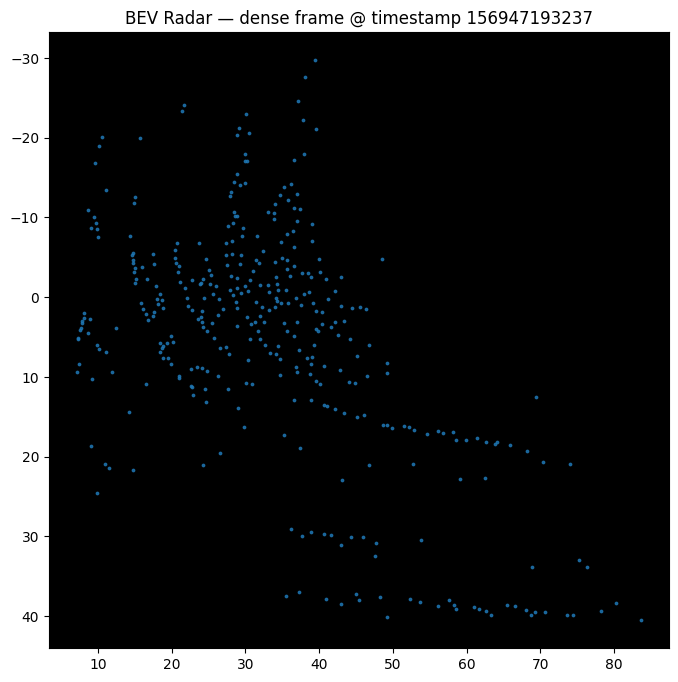

In [19]:
x = df_frame["range_sc"] * np.cos(df_frame["azimuth_sc"])
y = df_frame["range_sc"] * np.sin(df_frame["azimuth_sc"])

plt.figure(figsize=(8,8))
plt.scatter(x, y, s=3, alpha=0.8)
plt.gca().set_facecolor("black")
plt.title(f"BEV Radar — dense frame @ timestamp {t_good}")
plt.gca().invert_yaxis()
plt.show()


In [20]:
import joblib

model_path = "../models/rf.joblib"
model = joblib.load(model_path)

print("Model features:", model.feature_names_in_)


Model features: ['sensor_id' 'range_sc' 'azimuth_sc' 'rcs' 'vr' 'vr_compensated' 'x' 'y'
 'distance' 'angle_deg' 'speed_abs' 'power_norm']


In [21]:
# compute ML features exactly like training script
df_frame["x"] = df_frame["range_sc"] * np.cos(df_frame["azimuth_sc"])
df_frame["y"] = df_frame["range_sc"] * np.sin(df_frame["azimuth_sc"])

df_frame["distance"] = df_frame["range_sc"]
df_frame["angle_deg"] = np.degrees(df_frame["azimuth_sc"])
df_frame["speed_abs"] = np.abs(df_frame["vr_compensated"])
df_frame["power_norm"] = (df_frame["rcs"] - df_frame["rcs"].min()) / (
                            df_frame["rcs"].max() - df_frame["rcs"].min()
                        )


/tmp/ipykernel_1667987/736106433.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_frame["x"] = df_frame["range_sc"] * np.cos(df_frame["azimuth_sc"])
/tmp/ipykernel_1667987/736106433.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_frame["y"] = df_frame["range_sc"] * np.sin(df_frame["azimuth_sc"])
/tmp/ipykernel_1667987/736106433.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveat

In [22]:
model = joblib.load("../models/rf.joblib")
print(model.feature_names_in_)


['sensor_id' 'range_sc' 'azimuth_sc' 'rcs' 'vr' 'vr_compensated' 'x' 'y'
 'distance' 'angle_deg' 'speed_abs' 'power_norm']


In [23]:
features = list(model.feature_names_in_)
X_frame = df_frame[features]
y_pred = model.predict(X_frame)



In [24]:
# Pick the densest timestamp
counts = df.groupby("timestamp").size()
dense_ts = counts.sort_values(ascending=False).index.tolist()

t0 = dense_ts[0]  # <-- guaranteed non-empty
df_frame = df[df["timestamp"] == t0]


In [25]:
# Cartesian coords
df_frame["x"] = df_frame["range_sc"] * np.cos(df_frame["azimuth_sc"])
df_frame["y"] = df_frame["range_sc"] * np.sin(df_frame["azimuth_sc"])

# Derived features
df_frame["distance"] = df_frame["range_sc"]  # same as range_sc
df_frame["angle_deg"] = np.degrees(df_frame["azimuth_sc"])
df_frame["speed_abs"] = np.abs(df_frame["vr"])
df_frame["power_norm"] = (df_frame["rcs"] - df_frame["rcs"].min()) / (df_frame["rcs"].max() - df_frame["rcs"].min())


/tmp/ipykernel_1667987/2320925967.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_frame["x"] = df_frame["range_sc"] * np.cos(df_frame["azimuth_sc"])
/tmp/ipykernel_1667987/2320925967.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_frame["y"] = df_frame["range_sc"] * np.sin(df_frame["azimuth_sc"])
/tmp/ipykernel_1667987/2320925967.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cav

In [26]:
features = list(model.feature_names_in_)
X_frame = df_frame[features]

y_pred = model.predict(X_frame)
print("Predicted classes:", np.unique(y_pred))


Predicted classes: [ 0  1  2  3  7  8 10 11]


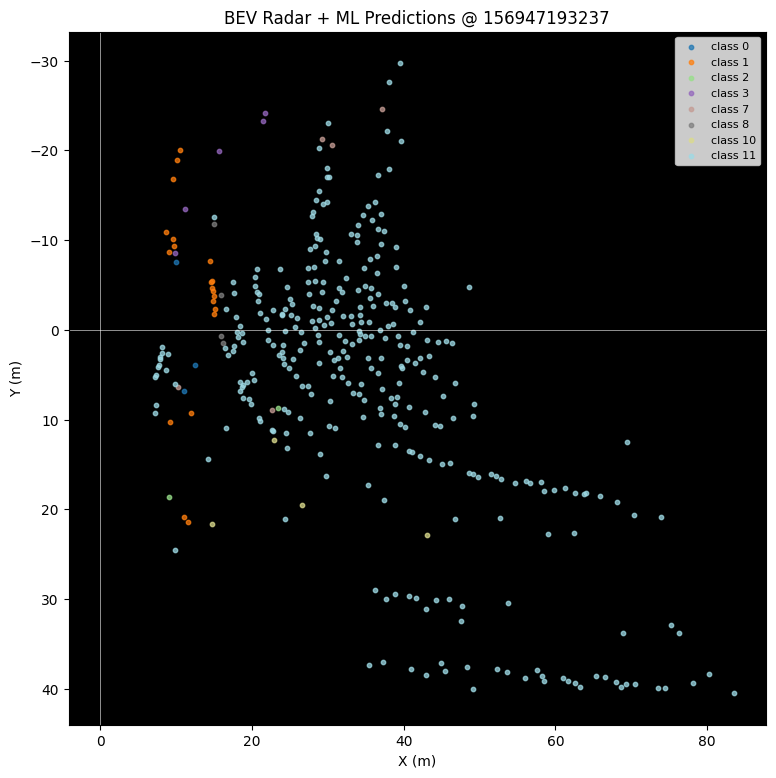

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Use the same XY coords
x = df_frame["range_sc"] * np.cos(df_frame["azimuth_sc"])
y = df_frame["range_sc"] * np.sin(df_frame["azimuth_sc"])

classes = np.unique(y_pred)
colors = plt.cm.tab20(np.linspace(0,1,len(classes)))  # 20-color map

plt.figure(figsize=(9,9))
plt.gca().set_facecolor("black")

for cls, color in zip(classes, colors):
    mask = (y_pred == cls)
    plt.scatter(
        x[mask], 
        y[mask], 
        s=10, 
        color=color,
        label=f"class {cls}",
        alpha=0.75
    )

plt.gca().invert_yaxis()
plt.axhline(0, color="white", linewidth=0.4)
plt.axvline(0, color="white", linewidth=0.4)
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title(f"BEV Radar + ML Predictions @ {t0}")
plt.legend(loc="upper right", fontsize=8)
plt.show()


In [28]:
CLASS_NAMES = {
    0: "car",
    1: "large vehicle / truck",
    2: "two wheeler",
    3: "pedestrian",
    4: "small pedestrian group",
    5: "van / pickup",
    6: "large vehicle",
    7: "motorcycle",
    8: "child pedestrian",
    9: "large pedestrian group",
    10: "unknown 4-wheeler",
    11: "noise"
}
CLASS_COLORS = {
    0: "#1f77b4",   # blue - car
    1: "#ff7f0e",   # orange - truck
    2: "#2ca02c",   # green - two wheeler
    3: "#d62728",   # red - pedestrian
    4: "#ff00ae2d", # magenta - pedestrian group   
    5: "#9467bd",   # purple - van/pickup
    6: "#e377c2",   # pink - large vehicle alt
    7: "#17becf",   # cyan - motorcycle
    8: "#bcbd22",   # yellow - child pedestrian
    9: "#8c564b",   # brown - ped group
    10: "#00bfa0",  # teal - unknown 4-wheeler
    11: "#c7c7c7",  # light gray - noise
}


In [29]:
label = CLASS_NAMES.get(cls, f"class {cls}")


In [30]:
from matplotlib import image as mpimg

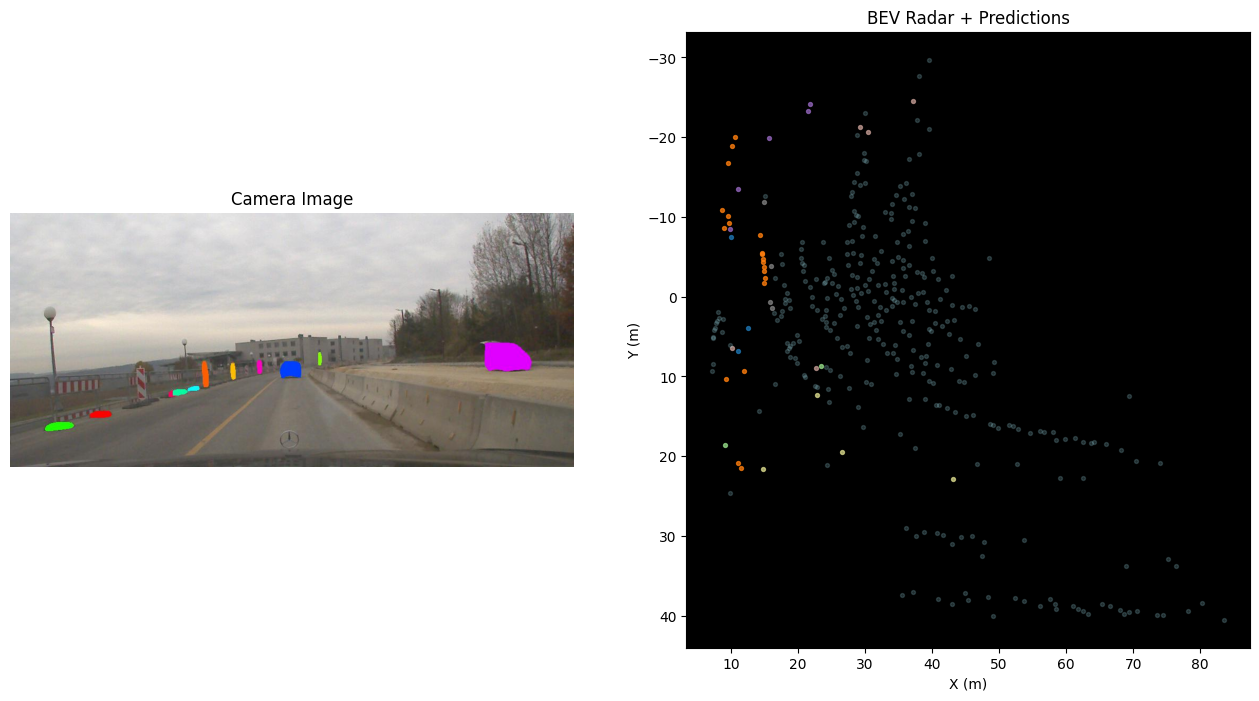

In [31]:
fig, ax = plt.subplots(1,2, figsize=(16,8))

# Load camera image properly
img_path = "/home/rraricha/Datasets/RadarScenes/RadarScenes/data/sequence_1/camera/156862567343.jpg"
img = mpimg.imread(img_path)

# Camera
ax[0].imshow(img)
ax[0].set_title("Camera Image")
ax[0].axis("off")

# BEV
ax[1].set_facecolor("black")
for cls, color in zip(classes, colors):
    mask = (y_pred == cls)

    alpha=0.20 if cls == 11 else 0.75

    ax[1].scatter(
        x[mask], y[mask], s=8, color=color, alpha=alpha
    )

ax[1].invert_yaxis()
ax[1].set_title("BEV Radar + Predictions")
ax[1].set_xlabel("X (m)")
ax[1].set_ylabel("Y (m)")
plt.show()


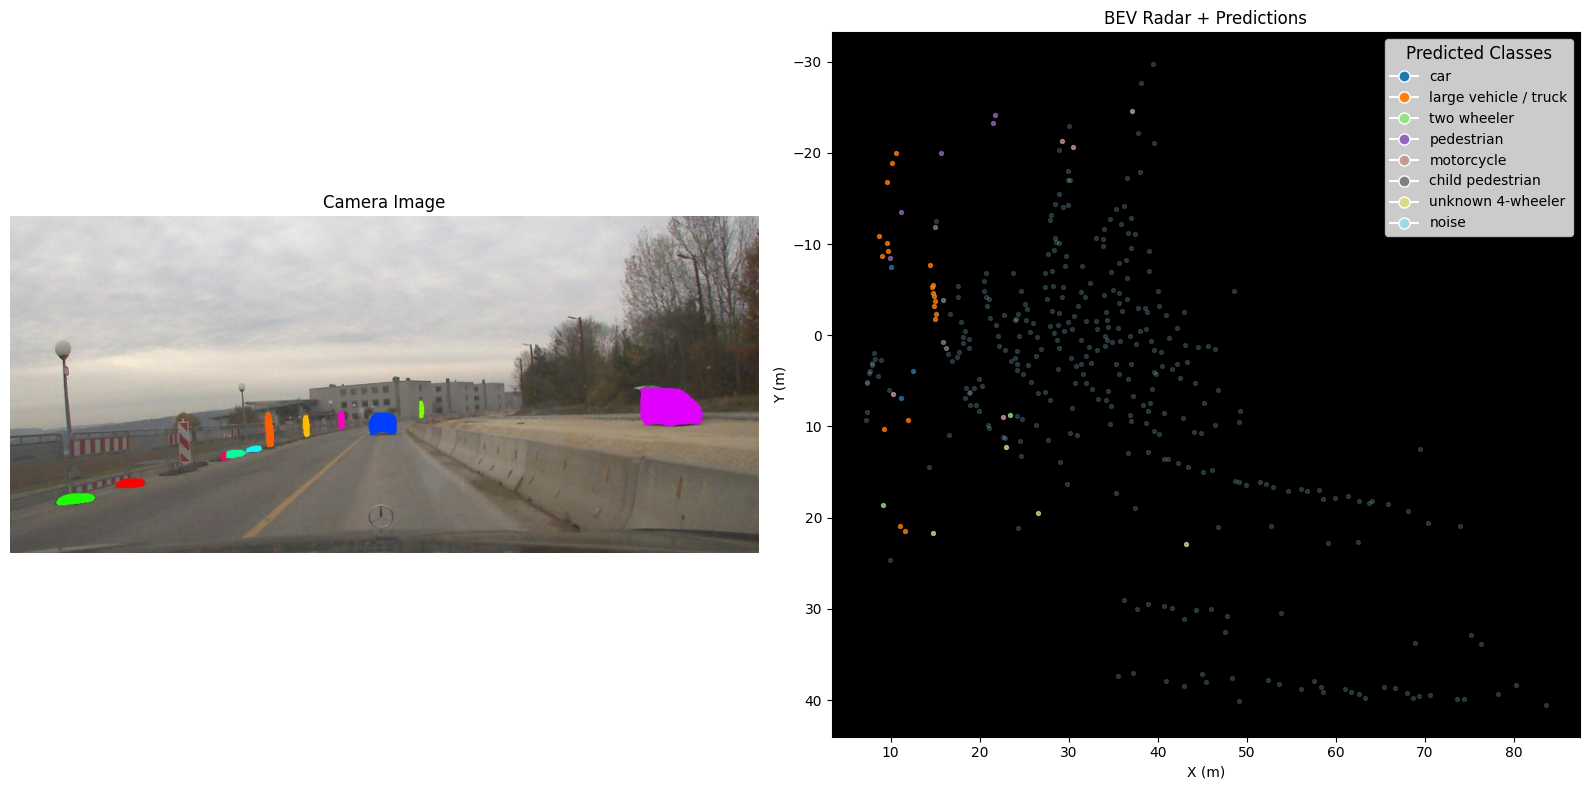

In [32]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1,2, figsize=(16,8))

# Load camera image properly
img_path = "/home/rraricha/Datasets/RadarScenes/RadarScenes/data/sequence_1/camera/156862567343.jpg"
img = mpimg.imread(img_path)

# Camera
ax[0].imshow(img)
ax[0].set_title("Camera Image")
ax[0].axis("off")

# BEV
ax[1].set_facecolor("black")

for cls, color in zip(classes, colors):
    mask = (y_pred == cls)

    alpha = 0.20 if cls == 11 else 0.75

    ax[1].scatter(
        x[mask], y[mask], s=8, color=color, alpha=alpha
    )

ax[1].invert_yaxis()
ax[1].set_title("BEV Radar + Predictions")
ax[1].set_xlabel("X (m)")
ax[1].set_ylabel("Y (m)")

# ---- Legend with CLASS_NAMES ----
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=color,
        markersize=8,
        label=CLASS_NAMES.get(cls, f"Class {cls}")  # fall back if missing
    )
    for cls, color in zip(classes, colors)
]

ax[1].legend(
    handles=legend_elements,
    title="Predicted Classes",
    loc="upper right",
    fontsize=10,
    title_fontsize=12
)

plt.tight_layout()
plt.show()


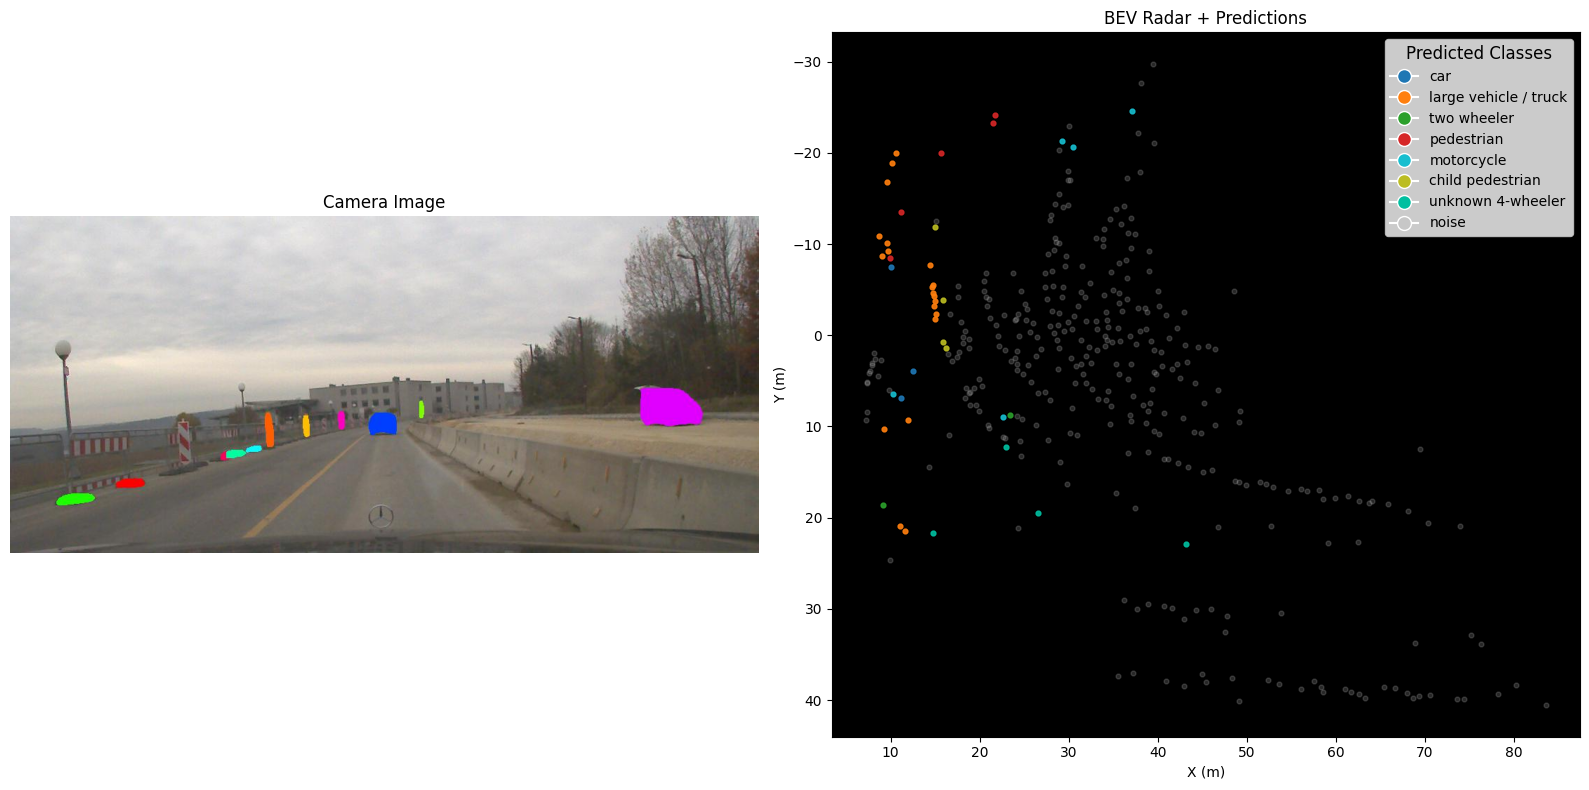

In [33]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.lines import Line2D

# Updated names
CLASS_NAMES = {
    0: "car",
    1: "large vehicle / truck",
    2: "two wheeler",
    3: "pedestrian",
    4: "small pedestrian group",
    5: "van / pickup",
    6: "large vehicle",
    7: "motorcycle",
    8: "child pedestrian",
    9: "large pedestrian group",
    10: "unknown 4-wheeler",
    11: "noise"
}
CLASS_COLORS = {
    0: "#1f77b4",   # blue - car
    1: "#ff7f0e",   # orange - truck
    2: "#2ca02c",   # green - two wheeler
    3: "#d62728",   # red - pedestrian
    4: "#ff00ae2d", # magenta - pedestrian group   
    5: "#9467bd",   # purple - van/pickup
    6: "#e377c2",   # pink - large vehicle alt
    7: "#17becf",   # cyan - motorcycle
    8: "#bcbd22",   # yellow - child pedestrian
    9: "#8c564b",   # brown - ped group
    10: "#00bfa0",  # teal - unknown 4-wheeler
    11: "#c7c7c7",  # light gray - noise
}
fig, ax = plt.subplots(1,2, figsize=(16,8))

# Camera image
img_path = "/home/rraricha/Datasets/RadarScenes/RadarScenes/data/sequence_1/camera/156862567343.jpg"
img = mpimg.imread(img_path)
ax[0].imshow(img)
ax[0].set_title("Camera Image")
ax[0].axis("off")

# BEV radar predictions
ax[1].set_facecolor("black")

for cls in classes:
    mask = (y_pred == cls)
    color = CLASS_COLORS.get(cls, "#ffffff")
    alpha = 0.20 if cls == 11 else 0.90
    ax[1].scatter(x[mask], y[mask], s=12, color=color, alpha=alpha)

ax[1].invert_yaxis()
ax[1].set_title("BEV Radar + Predictions")
ax[1].set_xlabel("X (m)")
ax[1].set_ylabel("Y (m)")

# Legend
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        markersize=10,
        color='w',
        markerfacecolor=CLASS_COLORS[cls],
        label=CLASS_NAMES[cls]
    )
    for cls in classes
]

ax[1].legend(
    handles=legend_elements,
    title="Predicted Classes",
    loc="upper right",
    fontsize=10,
    title_fontsize=12
)

plt.tight_layout()
plt.show()
